Problems: Kernel Density Estimation
---

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import norm


### Problem 1

Part a. sketch the ecdf

<Axes: ylabel='Proportion'>

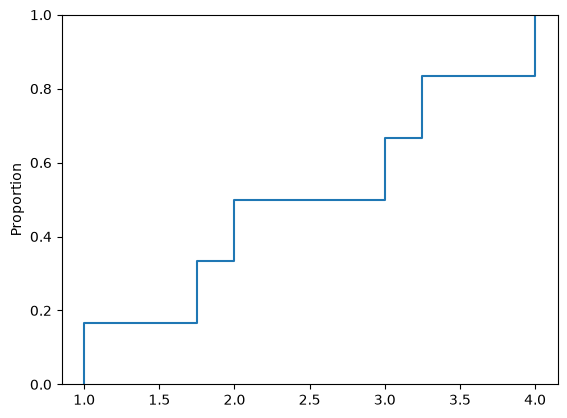

In [2]:
data = [1, 1.75, 2, 3, 3.25, 4]

sns.ecdfplot(data=data)


### for handwritten sketches
- length of data is n=6
- each time we pass an observation along the x axis, we add 1/6 proportion
- ex. 0-1: 0 on y
- 1-1.75, y=1/6
- 1.75 - 2, y = 2/6
- 2-2, y = 1/2
- 3-3.25, y = 4/6
- 3.25-4, y=5/6
- anything at 4 and above is straight line, y=6/6

Part b. sketch the uniform kernel density estimator with bandwidth of 0.2

In [3]:
def kde(X,K=30):
    n = len(X)
    X = np.array(X)
    h_u = 0.2
    x_grid = np.linspace( X.min()-2*h_u, X.max()+2*h_u, K) # Create a grid to plot
    I = np.abs( x_grid[:,None] - X[None,:]) < h_u # Broadcast the indicator comparison
    f_hat = np.sum(I,axis=1)/(2 * n * h_u) # Compute kde
    plt.step(x_grid,f_hat,where='mid')
    plt.fill_between(x_grid,f_hat,step='mid')
    plt.title('Uniform Kernel Density Estimator (Blocky)')
    plt.show()
    return x_grid, f_hat

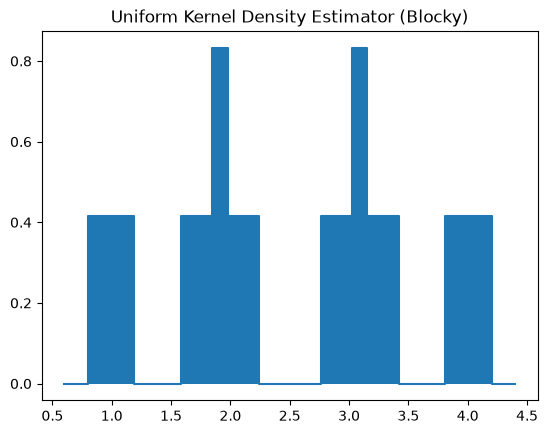

In [4]:
x_grid, f_hat = kde(data)

### for handsketching
1/(2nh) = 1/(2(6)(.2)) = .4167

1.0 : .8 - 1.2 --> .4167
- return to 0

1.75 : 1.55 - 1.95 --> .4167

2.0: 1.8 - 2.2 --> .4167 + .4167 for overlap between 1.8-1.95
- return to 0 after 2.2

3.0: 2.8 - 3.2 --> .4167

3.25: 3.05 - 3.45 --> .4167 + .4167 for overlap between 3.05 - 3.2
- return to 0 after 3.45

4.0: 3.8 - 4.2 --> .4167 
- return to 0 after 4.2

Part c. compute silverman bandwidth

In [5]:
# silverman bandwidth
df_data = pd.DataFrame(data)
h_u = 1.84 * df_data.std() * len(df_data) ** (-0.2) # Compute bandwidth
h_u


0    1.423166
dtype: float64

Part d. sketch the uniform kernel density estimator with silverman bandwidth

In [6]:
def kde(X,K=30):
    n = len(X)
    X = np.array(X)
    h_u = 1.423166
    x_grid = np.linspace( X.min()-2*h_u, X.max()+2*h_u, K) # Create a grid to plot
    I = np.abs( x_grid[:,None] - X[None,:]) < h_u # Broadcast the indicator comparison
    f_hat = np.sum(I,axis=1)/(2 * n * h_u) # Compute kde
    plt.step(x_grid,f_hat,where='mid')
    plt.fill_between(x_grid,f_hat,step='mid')
    plt.title('Uniform Kernel Density Estimator (Blocky)')
    plt.show()
    return x_grid, f_hat

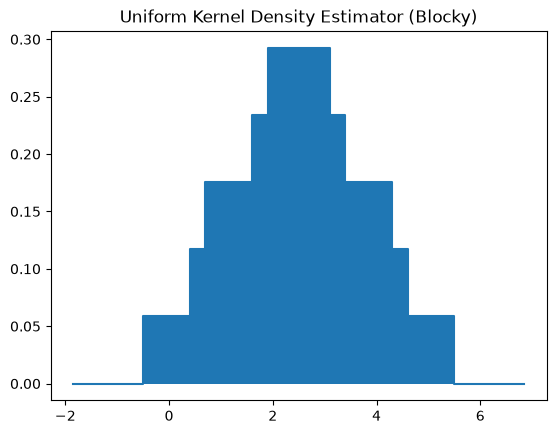

In [7]:
x_grid, f_hat = kde(data)

### for hand sketching
- similar process as part b, but we use bandwidth from Silverman, 1.4, in the 1/2nh

Part e. how are the 2 graphs similar or different

How they are different: bandwidth

With the graph from part b, the bandwidth is much smaller than the Silverman bandwidth, resulting in less overlap, more empty spaces, and less continuity in the visualization. With the graph from part d, the bandwidth is much larger, so there is more overlapping resulting in a smoother visual. 

How are they similar: the data
Both graphs are visualizing the same data.

Problem 2
---

In [8]:
data = [-1, -0.5, 0, 0.5, 1]

Part a. Using the uniform kernel with h = 0.6, compute the realized KDE at x = 0, f_hat_h(0), directly from these five numbers.


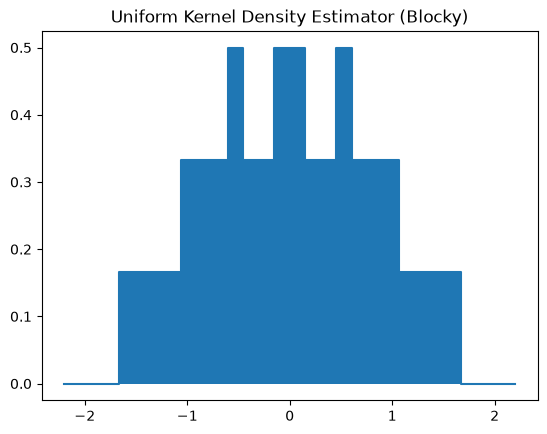

In [9]:
def kde(X,K=30):
    n = len(X)
    X = np.array(X)
    h_u = .6
    x_grid = np.linspace( X.min()-2*h_u, X.max()+2*h_u, K) # Create a grid to plot
    I = np.abs( x_grid[:,None] - X[None,:]) < h_u # Broadcast the indicator comparison
    f_hat = np.sum(I,axis=1)/(2 * n * h_u) # Compute kde
    plt.step(x_grid,f_hat,where='mid')
    plt.fill_between(x_grid,f_hat,step='mid')
    plt.title('Uniform Kernel Density Estimator (Blocky)')
    plt.show()
    return x_grid, f_hat

x_grid, f_hat = kde(data)

f_hat_h(0) = 0.5

![alt text](IMG_5710.jpeg)

b. Now compute E[f_hat_h(0)] at the same h = 0.6.


In [10]:
# E[x] = CDF(F_hat(x+h) - F_hat(x-h))/2h = CDF(.6) - CDF(-.6) = P(-.6 < x < 0.6)
cdf2 = norm.cdf(0.6)
cdf1 = norm.cdf(-0.6)

e_x = (cdf2 - cdf1) / (2*.6)
e_x

print(f'E[f_hat_h(0)]={e_x}')


E[f_hat_h(0)]=0.3762448037498774


c. Calculate the true density at x=0, using the Normal distribution.


In [11]:
# true density, f(0), which is pdf
# normal dist: f(x) = 1/sqrt(2pi) * e^(-x squared / 2)
# or scipy command
true_density = norm.pdf(0)
print(true_density)

0.3989422804014327


In [12]:
0.3762448037498774 - 0.3989422804014327

-0.022697476651555304

d. Are b and c equal? What does this mean about bias? (Keep in mind, truly proving anything about bias would require us to compare E[f_hat_h] to the Normal distribution for all x; calculating this at one point is only an indication of what is going on that you can extrapolate from.)

B and c values are not equal. We know that the expectation of the KDE is consistent, but is also biased, so it is not equal to the pdf. The KDE is negatively biased at x = 0 because E[f_hat_h(0)] is less than f(0). 

e. Recompute E[f_hat_h(0)] from (b) at a much smaller bandwidth, h = 0.1. What happens to the gap between E[f_hat_h(0)] and f(0) as h shrinks?

The difference between the KDE expectation and the pdf decreases as the bandwidth shrinks

In [13]:
# E[x] = CDF(F_hat(x+h) - F_hat(x-h))/2h = CDF(.1) - CDF(-.1) = P(-.1 < x < 0.1)
cdf2 = norm.cdf(0.1)
cdf1 = norm.cdf(-0.1)

e_x = (cdf2 - cdf1) / (2*.1)
e_x

print(f'E[f_hat_h(0)]={e_x}')


E[f_hat_h(0)]=0.3982783727702899


In [14]:
new_gap = e_x - 0.3989422804014327
new_gap

np.float64(-0.0006639076311428238)

f. Is f_hat_h a consistent estimator? Explain your reasoning.

f_hat_h or the KDE is a consistent estimator because as the sample size gets bigger, the KDE tends to be more accurate. As the bandwidth, h,  approaches 0 when n is increasing, the KDE bias also approaches 0. 

g. What are the main considerations in choosing a bandwidth value h?

When choosing bandwidth, I would want to consider how smooth the visualization would be based off of the bandwdith. For example, if I wanted to clearly see every detail, I would have a much smaller bandwidth. If I wanted a smoother visual and was not concerned about details, I would want a larger bandwidth. 

Problem 3
---

In [15]:
data = [5, 7, 7, 8, 10] 
#  fix the bandwidth at h = 1.5

Part a. Compute the uniform-kernel KDE, f_hat_h(x), at x = 6.0, x = 6.5, x = 7.0, x = 8.0, and x = 8.5.


In [16]:
def uniform_kernel(vals, data, h):
    w = 1/(2*h*len(data))
    values = []
    for v in vals:
        count = 0
        low_b = v-h
        high_b = v+h
        for j in data:
            if (j > low_b) and (j < high_b):
                count += 1
        f_hat = count * w
        values.append(f_hat)
    return values

x_points = [6.0, 6.5, 7.0, 8.0, 8.5]
data = [5,7,7,8,10]
values = uniform_kernel(x_points, data, h=1.5)

for x, vals in zip(x_points, values):
    print(f'{x}, {vals}')

6.0, 0.2
6.5, 0.13333333333333333
7.0, 0.2
8.0, 0.2
8.5, 0.06666666666666667


b. Compute the Gaussian-kernel KDE at the same five values of x, using the same h = 1.5.


$$
\hat{f}_h(x) = \dfrac{1}{nh} \sum_{i=1}^n \dfrac{1}{\sqrt{2\pi}} \exp \left( -\frac{1}{2} \left( \dfrac{x_i-x}{h}\right)^2\right)
$$

In [17]:
def calc_gaussian(x_points, data, h):
    n = len(data)
    vals = []

    for i in x_points:
        sum = 0
        for j in data:
            e = np.exp((-.5)*np.square((i-j)/h))
            sum+=e
        f_hat = sum / (n*h*np.sqrt(2*np.pi))
        vals.append(f_hat)

    return vals

x_points = [6, 6.5, 7, 8, 8.5]
values = calc_gaussian(x_points, data, h=1.5)

for x, vals in zip(x_points, values):
    print(f'{x}, {vals}')

6, 0.151166676968913
6.5, 0.16865730580239768
7, 0.1780444810019199
8, 0.16744524435137584
8.5, 0.15060230537921768


part c.

The biggest jump in the uniform kde is the from x value 8.0 at 2 to x value 8.5 at 0.067. The uniform case has this abrupt jump because the f_hat is computed by multiplying the amount of data points captured by 1/2nh. This calculation creates rectangular shapes by cutting off at the bandwidth, h. For the large jump specifically, the value 8 has the bandwidth range (6.5, 9.5) exclusive encompassing 3 data points, 7, 7, 8. The value 8.5 has a bandwidth range of (7, 10) exclusive, so it only encompasses 1 data point, 8. 

In the Gaussian case, the individuals shapes are not rectangles, but bell-shaped curves. These curves are created from the squared exponentials in the Gaussian KDE formula, so the values have less differences between them.

part d.

I may prefer the uniform case if I need specific details from the visual. For example, if I want to compare to separate x values, I would want to see any large jumps from rectangle to rectangle. I would prefer the gaussian case if I was interested in the overall, general look of the data.

Problem 4
---

In [18]:
data = pd.read_csv('./data/heart_failure_clinical_records_dataset.csv')

In [19]:
data.head(3)

,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,time,DEATH_EVENT
0,75.0,0,582,0,20,1,265000.00,1.9,130,1,0,4,1
1,55.0,0,7861,0,38,0,263358.03,1.1,136,1,0,6,1
2,65.0,0,146,0,20,0,162000.00,1.3,129,1,1,7,1


plot b.

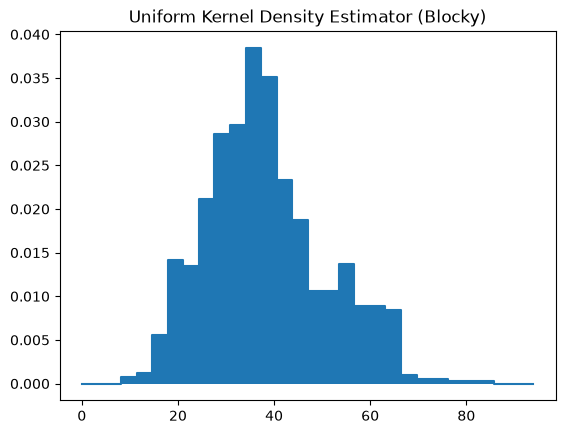

(array([ 0.09571897,  3.33049697,  6.56527498,  9.80005298, 13.03483098,
        16.26960898, 19.50438698, 22.73916499, 25.97394299, 29.20872099,
        32.44349899, 35.67827699, 38.913055  , 42.147833  , 45.382611  ,
        48.617389  , 51.852167  , 55.086945  , 58.32172301, 61.55650101,
        64.79127901, 68.02605701, 71.26083501, 74.49561302, 77.73039102,
        80.96516902, 84.19994702, 87.43472502, 90.66950303, 93.90428103]),
 array([0.        , 0.        , 0.        , 0.00072161, 0.00120268,
        0.00553233, 0.01419163, 0.01347002, 0.02116718, 0.0286238 ,
        0.02958594, 0.03848578, 0.03511827, 0.023332  , 0.01876182,
        0.01058359, 0.01058359, 0.01371056, 0.00889984, 0.00889984,
        0.00841876, 0.00096214, 0.00048107, 0.00048107, 0.00024054,
        0.00024054, 0.00024054, 0.        , 0.        , 0.        ]))

In [20]:
def kde(X,K=30):
    n = len(X)
    X = np.array(X)
    h_u = 1.84 * X.std() * n ** (-0.2) # Compute bandwidth
    x_grid = np.linspace( X.min()-2*h_u, X.max()+2*h_u, K) # Create a grid to plot
    I = np.abs( x_grid[:,None] - X[None,:]) < h_u # Broadcast the indicator comparison
    f_hat = np.sum(I,axis=1)/(2 * n * h_u) # Compute kde
    plt.step(x_grid,f_hat,where='mid')
    plt.fill_between(x_grid,f_hat,step='mid')
    plt.title('Uniform Kernel Density Estimator (Blocky)')
    plt.show()
    return x_grid, f_hat

kde(data['ejection_fraction'])

[Text(0.5, 1.0, 'Gaussian KDE (Smooth)')]

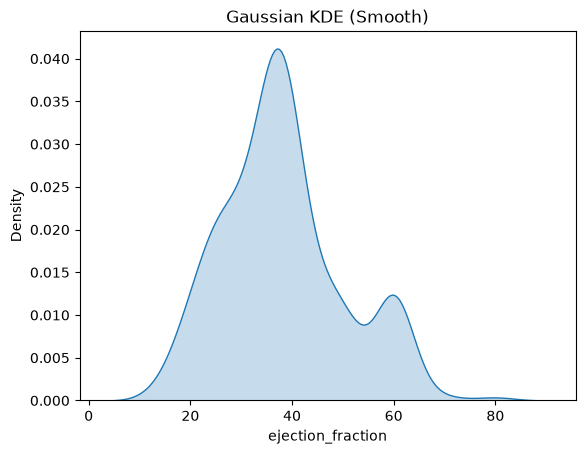

In [21]:
sns.kdeplot( data = data, x = 'ejection_fraction', fill = True).set(title='Gaussian KDE (Smooth)')

<function matplotlib.pyplot.show(close=None, block=None)>

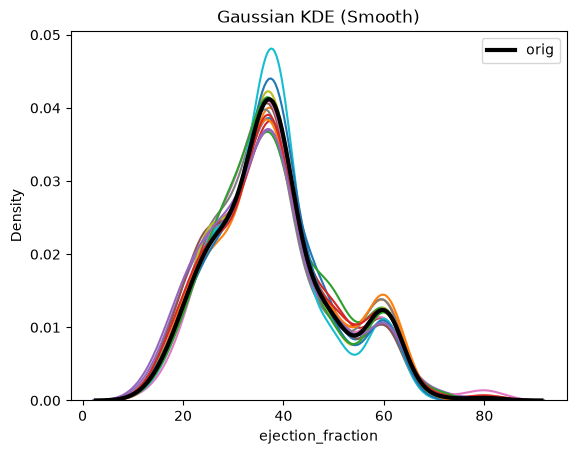

In [31]:
for i in range(15):
    sample = data.sample(frac=1.0, replace=True)
    sns.kdeplot( data = sample, x = 'ejection_fraction', fill = False).set(title='Gaussian KDE (Smooth)')


sns.kdeplot(data=data, x='ejection_fraction', label='orig', color='black', linewidth='3')
plt.legend()
plt.show

part d.

The values of ejection_fraction that appear relatively reliable are where all 16 line are tightly overlapping. This would be x values from around 40 to about 48 and about 63 to 80.

The areas where there is noticeable variation in the reseampled data is where the lines are spaced out from each other. This would be at the peak of the x values at about 37 and from about 45 to 60. 